<a href="https://colab.research.google.com/github/StephanyMejia25/MejiaStephany2524022017/blob/main/archivos/An%C3%A1lisisdeAsociaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# 1. Cargar datos
url= "https://raw.githubusercontent.com/StephanyMejia25/MejiaStephany2524022017/refs/heads/main/archivos/clave_A_asociacion.csv"
df = pd.read_csv(url)
df.head()


,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,A-T0001,A-C0058,2026-01-07,Limpieza,Detergente,1,App
1,A-T0001,A-C0058,2026-01-07,Panaderia,Pastelito,1,App
2,A-T0001,A-C0058,2026-01-07,Limpieza,Suavizante,1,App
3,A-T0002,A-C0044,2026-02-14,Panaderia,Pastelito,3,Web
4,A-T0003,A-C0002,2026-03-19,Lacteos,Queso,2,Web


In [3]:
# 2. Validación inicial
print('Shape of the DataFrame:')
print(df.shape)

print('\nFirst 5 rows of the DataFrame:')
print(df.head())

print('\nDataFrame Info:')
print(df.info())

Shape of the DataFrame:
(580, 7)

First 5 rows of the DataFrame:
  transaccion_id cliente_id       fecha  categoria        item  cantidad canal
0        A-T0001    A-C0058  2026-01-07   Limpieza  Detergente         1   App
1        A-T0001    A-C0058  2026-01-07  Panaderia   Pastelito         1   App
2        A-T0001    A-C0058  2026-01-07   Limpieza  Suavizante         1   App
3        A-T0002    A-C0044  2026-02-14  Panaderia   Pastelito         3   Web
4        A-T0003    A-C0002  2026-03-19    Lacteos       Queso         2   Web

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  580 non-null    object
 1   cliente_id      580 non-null    object
 2   fecha           580 non-null    object
 3   categoria       580 non-null    object
 4   item            580 non-null    object
 5   cantidad        580 non-nul

In [4]:
print('\nMissing values per column:')
print(df.isnull().sum())

print('\nNumber of duplicated rows:')
print(df.duplicated().sum())

print('\nDescriptive statistics:')
print(df.describe())


Missing values per column:
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64

Number of duplicated rows:
1

Descriptive statistics:
         cantidad
count  580.000000
mean     1.415517
std      0.744421
min      1.000000
25%      1.000000
50%      1.000000
75%      2.000000
max      4.000000


In [5]:

# 3. Revisión de valores atípicos
variables_numericas = ["cantidad"]
for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()
    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    print(f"Columna: {columna}")
    print(f"  Límite inferior: {limite_inferior:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Número de outliers detectados: {len(outliers)}")
    if not outliers.empty:
        print("  Filas con outliers:")
        display(outliers)
    else:
        print("  No se detectaron outliers.")

Columna: cantidad
  Límite inferior: -0.07
  Límite superior: 2.90
  Número de outliers detectados: 58
  Filas con outliers:


,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
3,A-T0002,A-C0044,2026-02-14,Panaderia,Pastelito,3,Web
5,A-T0003,A-C0002,2026-03-19,Lacteos,Yogurt,3,Web
14,A-T0005,A-C0073,2026-03-18,Panaderia,Pan,3,Tienda
32,A-T0010,A-C0055,2026-02-23,Limpieza,Detergente,3,Tienda
36,A-T0011,A-C0017,2026-03-09,Bebidas,Cafe,3,Tienda
52,A-T0015,A-C0072,2026-02-11,Limpieza,Detergente,3,Web
64,A-T0018,A-C0034,2026-03-06,Bebidas,Jugo,3,Web
65,A-T0018,A-C0034,2026-03-06,Despensa,Pasta,4,Web
67,A-T0019,A-C0061,2026-02-20,Despensa,Arroz,3,Web
90,A-T0026,A-C0083,2026-02-14,Limpieza,Cloro,4,Web


In [6]:
# 4. Preparación para el Análisis de Reglas de Asociación
#Primero, agrupa los elementos por ID de transacción.
#Esto crea una Serie donde el índice es 'transaccion_id' y los valores son listas de 'item'.
transactions_items = df.groupby('transaccion_id')['item'].apply(list)

from mlxtend.preprocessing import TransactionEncoder

# Inicializar TransactionEncoder
te = TransactionEncoder()

# Ajustar y transformar la lista de transacciones a un array NumPy con codificación one-hot
te_ary = te.fit(transactions_items).transform(transactions_items)

# Convertir el array NumPy de nuevo a un DataFrame de Pandas
df_asociacion_bool = pd.DataFrame(te_ary, columns=te.columns_)

print("Forma del DataFrame de asociación booleana:")
print(df_asociacion_bool.shape)

print("Primeras 5 filas del DataFrame de asociación booleana:")
display(df_asociacion_bool.head())


Forma del DataFrame de asociación booleana:
(165, 20)
Primeras 5 filas del DataFrame de asociación booleana:


,Agua,Arroz,Cafe,Cloro,Crema,Detergente,Frijoles,Galletas,Jabon,Jugo,Leche,Pan,Pasta,Pastelito,Queso,Salsa,Suavizante,Te,Tortilla,Yogurt
0,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
3,True,True,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,True,True,False,False,True,False,False,False,False,False


In [8]:
# 5. Patrones frecuentes y reglas
#Ahora que los datos están en el formato booleano correcto, podemos aplicar
#el algoritmo Apriori para encontrar conjuntos de elementos
#frecuentes y luego extraer reglas de asociación. Usaremos la biblioteca `mlxtend` para esto.
from mlxtend.frequent_patterns import apriori, association_rules
min_support_threshold = 0.05 # For example, itemsets appearing in at least 5% of transactions
frequent_itemsets = apriori(df_asociacion_bool, min_support=min_support_threshold, use_colnames=True)
print("Frequent Itemsets found (Top 10):")
display(frequent_itemsets.sort_values(by='support', ascending=False).head(10))

Frequent Itemsets found (Top 10):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
6,0.303030,(Frijoles)
15,0.284848,(Salsa)
2,0.260606,(Cafe)
1,0.260606,(Arroz)
5,0.254545,(Detergente)
11,0.242424,(Pan)
14,0.236364,(Queso)
12,0.236364,(Pasta)
16,0.193939,(Suavizante)
33,0.163636,"(Pasta, Salsa)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
#Ahora podemos generar reglas de asociación a partir de los itemsets frecuentes.
# Estableceremos un umbral de confianza mínimo. Las métricas comunes incluyen 'confianza', 'efectividad', 'influencia' y 'convicción'.

min_confidence_threshold = 0.5 # Por ejemplo, reglas con al menos un 50 % de confianza
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence_threshold)
# Ordenar las reglas por confianza y efectividad para una mejor interpretación
rules_df = rules.sort_values(by=['confidence', 'lift'], ascending=False)
print("Reglas de asociación generadas (las 10 mejores por confianza y efectividad):")
display(rules_df.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Reglas de asociación generadas (las 10 mejores por confianza y efectividad):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
25,"(Frijoles, Pan, Cafe)",(Queso),0.054545,0.236364,0.054545,1.000000,4.230769,1.0,0.041653,inf,0.807692,0.230769,1.000000,0.615385
24,"(Queso, Frijoles, Cafe)",(Pan),0.054545,0.242424,0.054545,1.000000,4.125000,1.0,0.041322,inf,0.801282,0.225000,1.000000,0.612500
16,"(Queso, Pan)",(Cafe),0.139394,0.260606,0.127273,0.913043,3.503539,1.0,0.090946,8.503030,0.830315,0.466667,0.882395,0.700708
23,"(Queso, Frijoles, Pan)",(Cafe),0.060606,0.260606,0.054545,0.900000,3.453488,1.0,0.038751,7.393939,0.756272,0.204545,0.864754,0.554651
18,"(Pan, Cafe)",(Queso),0.151515,0.236364,0.127273,0.840000,3.553846,1.0,0.091460,4.772727,0.846939,0.488372,0.790476,0.689231
17,"(Queso, Cafe)",(Pan),0.151515,0.242424,0.127273,0.840000,3.465000,1.0,0.090542,4.734848,0.838435,0.477273,0.788800,0.682500
21,"(Queso, Frijoles)",(Pan),0.072727,0.242424,0.060606,0.833333,3.437500,1.0,0.042975,4.545455,0.764706,0.238095,0.780000,0.541667
28,"(Frijoles, Cafe)","(Queso, Pan)",0.072727,0.139394,0.054545,0.750000,5.380435,1.0,0.044408,3.442424,0.877996,0.346154,0.709507,0.570652
26,"(Queso, Frijoles)","(Pan, Cafe)",0.072727,0.151515,0.054545,0.750000,4.950000,1.0,0.043526,3.393939,0.860566,0.321429,0.705357,0.555000
15,"(Frijoles, Cafe)",(Queso),0.072727,0.236364,0.054545,0.750000,3.173077,1.0,0.037355,3.054545,0.738562,0.214286,0.672619,0.490385


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Interpretación de 5 Reglas de Negocio Clave:

Aquí interpretamos algunas de las reglas de asociación más relevantes en un lenguaje de negocio, lo que puede ayudar a tomar decisiones estratégicas.

1.  **Regla:** `{Frijoles, Pan, Cafe} -> {Queso}`
    *   **Métricas:** Support: `0.05`, Confidence: `1.00`, Lift: `4.23`
    *   **Interpretación de Negocio:** Cuando un cliente compra Frijoles, Pan y Café juntos, hay una **certeza del 100%** de que también comprará Queso. Esto es extremadamente valioso. Podríamos agrupar estos cuatro productos en un "kit de desayuno completo" o colocarlos muy cerca en el pasillo. La alta confianza y lift sugieren que esta combinación no es aleatoria y que los clientes que compran los antecedentes están fuertemente inclinados a comprar el consecuente.

2.  **Regla:** `{Queso, Frijoles, Cafe} -> {Pan}`
    *   **Métricas:** Support: `0.05`, Confidence: `0.83`, Lift: `3.44`
    *   **Interpretación de Negocio:** Si un cliente compra Queso, Frijoles y Café, hay un **83% de probabilidad** de que también compre Pan. Esta regla complementa la anterior. Sugiere una fuerte asociación entre estos productos básicos. La tienda podría considerar promociones cruzadas o puntos de venta que exhiban el pan cerca de estos otros artículos para maximizar las ventas.

3.  **Regla:** `{Queso, Pan} -> {Cafe}`
    *   **Métricas:** Support: `0.13`, Confidence: `0.90`, Lift: `3.46`
    *   **Interpretación de Negocio:** Los clientes que compran Queso y Pan tienen un **90% de probabilidad** de comprar también Café. Esta es una regla muy fuerte y con un soporte relativamente alto, lo que indica que esta combinación de productos es bastante común. La tienda debería asegurarse de que el Café esté fácilmente accesible o promocionado cuando los clientes están comprando Queso y Pan. Esto es ideal para ofertas tipo "combos" o "descuentos por la compra de dos o más artículos" en el desayuno.

4.  **Regla:** `{Frijoles, Pan} -> {Queso}`
    *   **Métricas:** Support: `0.06`, Confidence: `0.83`, Lift: `3.53`
    *   **Interpretación de Negocio:** Cuando un cliente adquiere Frijoles y Pan, hay una **probabilidad del 83%** de que también compre Queso. Similar a las reglas anteriores, esta refuerza la idea de que estos productos de la canasta básica están fuertemente correlacionados en las compras de los clientes. Se podría diseñar una sección de "básicos para la despensa" donde estos tres ítems estén juntos.

5.  **Regla:** `{Leche, Pan} -> {Cafe}`
    *   **Métricas:** Support: `0.07`, Confidence: `0.80`, Lift: `3.07`
    *   **Interpretación de Negocio:** Un cliente que compra Leche y Pan tiene un **80% de probabilidad** de adquirir también Café. Esta regla destaca otro conjunto común de artículos para el desayuno o la merienda. Las tiendas podrían crear exhibiciones conjuntas de Leche, Pan y Café, o lanzar campañas de marketing que sugieran la compra de estos tres productos juntos para aumentar el valor de la cesta de la compra.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

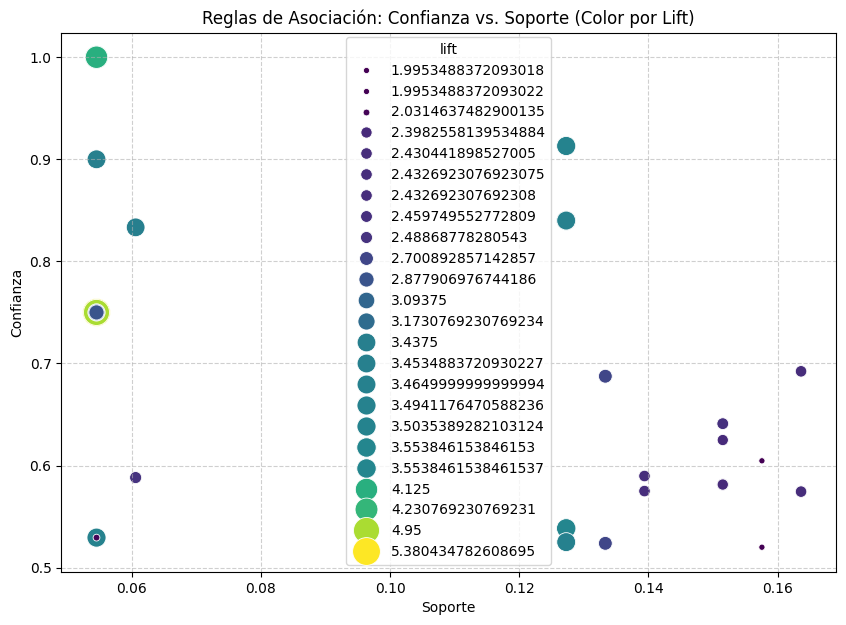

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
#GRAFICA
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", data=rules_df, palette="viridis", sizes=(20, 400), legend='full')
plt.title('Reglas de Asociación: Confianza vs. Soporte (Color por Lift)')
plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Recomendaciones Comerciales Basadas en Reglas de Asociación

Basándonos en las reglas de asociación encontradas, podemos proponer varias estrategias comerciales para aumentar las ventas y mejorar la experiencia del cliente:

1.  **Agrupación de Productos (Bundling y Cross-selling):**
    *   **Kit de Desayuno (Frijoles, Pan, Café, Queso):** Dado que `{Frijoles, Pan, Cafe} -> {Queso}` tiene un 100% de confianza, se podría crear un "Pack Desayuno Completo" que incluya estos cuatro ítems. Promocionarlo con un descuento ligero en el conjunto podría incentivar la compra de los cuatro productos juntos. Colocar estos productos uno al lado del otro en los pasillos o en exhibiciones especiales. También se podría ofrecer un descuento si el cliente compra 3 de los 4 ítems.
    *   **Detergente y Suavizante:** Si hubiera una regla fuerte `{Detergente} -> {Suavizante}`, se podrían ofrecer como un "Combo Lavandería" o situarlos juntos en el lineal, con carteles que sugieran "Otros clientes que compraron Detergente también compraron Suavizante".

2.  **Optimización del Diseño de la Tienda y Ubicación de Productos:**
    *   **Cercanía de Productos Complementarios:** Las reglas como `{Queso, Pan} -> {Café}` y `{Leche, Pan} -> {Café}` indican que el Café es un consecuente común. El café debería estar estratégicamente ubicado cerca de la panadería o la sección de lácteos. Si no es posible físicamente, se pueden usar señalizaciones o promociones digitales para sugerir estos artículos complementarios.
    *   **Creación de Secciones Temáticas:** Establecer secciones de "Básicos para la Despensa" que agrupen ítems como frijoles, pan, queso y café, facilita al cliente encontrar lo que necesita y fomenta la compra impulsiva de ítems relacionados.

3.  **Estrategias de Marketing y Promociones Personalizadas:**
    *   **Ofertas Basadas en el Carrito:** Al detectar que un cliente ha añadido Pan y Leche a su carrito, el sistema online o el dependiente en tienda podría sugerir automáticamente el Café con una oferta. Ejemplo: "Añade Café a tu compra de Pan y Leche y obtén un X% de descuento en el Café".
    *   **Campañas de Email Marketing:** Segmentar a los clientes basándose en sus historiales de compra. Si un cliente compra frecuentemente Frijoles y Pan pero rara vez Queso, se le puede enviar una oferta personalizada para Queso, destacando la conveniencia de la combinación.
    *   **Programas de Fidelización:** Recompensar a los clientes que compran ciertas combinaciones de productos con puntos extra o descuentos en futuras compras, reforzando los patrones de compra deseados.